In [1]:
import requests
import pandas as pd


!pip install streamlit plotly


In [206]:
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart?vs_currency=usd&days=30"


params = {
    "vs_currency" : "usd",
    "days" : 30
}

response = requests.get(url, params=params)
data = response.json()

data.keys()


dict_keys(['prices', 'market_caps', 'total_volumes'])

In [207]:
prices = data["prices"]


df = pd.DataFrame(prices, columns = ["timestamp", "price"])

df["date"] = pd.to_datetime(df["timestamp"], unit = "ms")

df = df[["date", "price"]] # simply keeps the necessary columns

df["daily_return"] = df["price"].pct_change()

df["daily_return_percent"] = df["daily_return"] * 100


df = df.rename(columns = {"daily_return" : "return", "daily_return_percent" : "return_percent"}) # way of renaming two of the columns

df.head()


,date,price,return,return_percent
0,2026-04-27 02:00:24.503,79217.036694,NaN,NaN
1,2026-04-27 03:00:12.333,79161.169035,-0.000705,-0.070525
2,2026-04-27 04:01:00.515,79096.323384,-0.000819,-0.081916
3,2026-04-27 05:00:08.318,78918.267500,-0.002251,-0.225113
4,2026-04-27 06:00:33.628,77819.819097,-0.013919,-1.391881


In [208]:
current_price = df["price"].iloc[-1]

start_price = df["price"].iloc[0]

total_return = (current_price - start_price) / start_price
avg_return = df["return"].mean()
volatility = df["return"].std()

df


,date,price,return,return_percent
0,2026-04-27 02:00:24.503,79217.036694,NaN,NaN
1,2026-04-27 03:00:12.333,79161.169035,-0.000705,-0.070525
2,2026-04-27 04:01:00.515,79096.323384,-0.000819,-0.081916
3,2026-04-27 05:00:08.318,78918.267500,-0.002251,-0.225113
4,2026-04-27 06:00:33.628,77819.819097,-0.013919,-1.391881
...,...,...,...,...
716,2026-05-26 22:01:38.552,75918.453853,-0.001002,-0.100232
717,2026-05-26 23:01:13.644,75636.672633,-0.003712,-0.371163
718,2026-05-27 00:01:38.949,75824.063325,0.002478,0.247751
719,2026-05-27 01:02:36.318,75847.708919,0.000312,0.031185


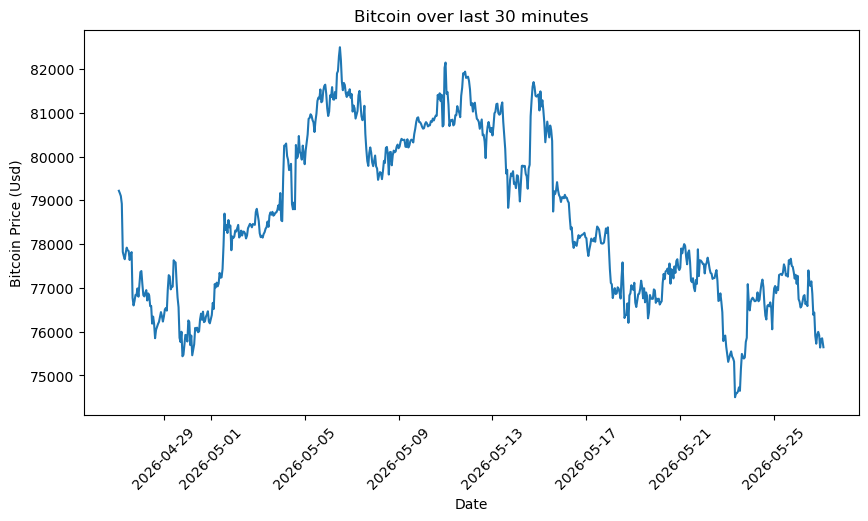

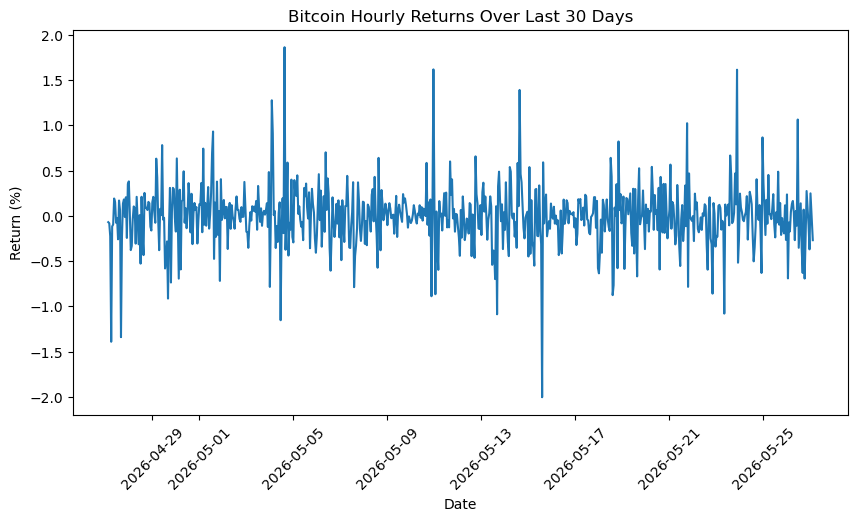

In [209]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 5))
plt.plot(df["date"], df["price"])
plt.xlabel("Date")
plt.ylabel("Bitcoin Price (Usd)")
plt.title("Bitcoin over last 30 minutes")
plt.xticks(rotation = 45) #rotates x lables 45 seconds in this case the dates 
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["return_percent"])
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.title("Bitcoin Hourly Returns Over Last 30 Days")
plt.xticks(rotation=45)
plt.show()




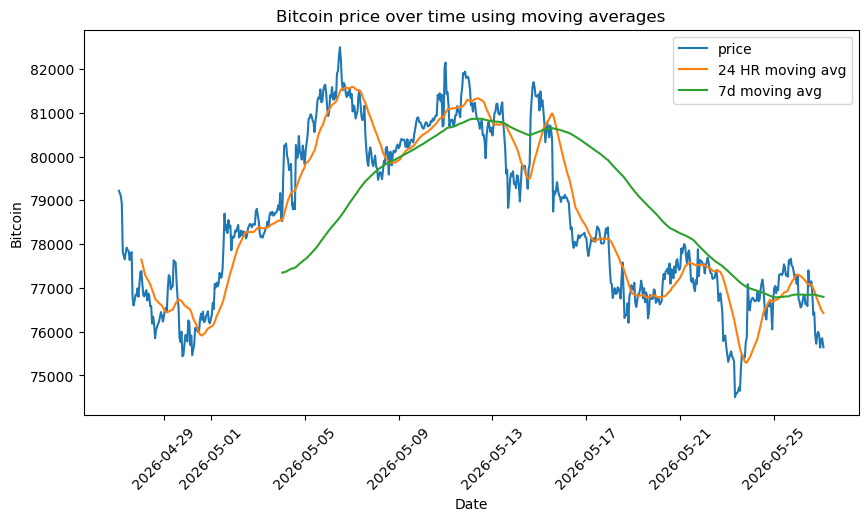

In [210]:
df["ma_24h"] = df["price"].rolling(window=24).mean()
df["ma_7d"] = df["price"].rolling(window = 24 * 7).mean() # calculates rolling price mean over 24 days including current and 23 behind

plt.figure(figsize = (10, 5))
plt.plot(df["date"], df["price"],label = "price")
plt.plot(df["date"], df["ma_24h"], label = "24 HR moving avg")
plt.plot(df["date"], df["ma_7d"], label = "7d moving avg")

plt.xlabel("Date")
plt.ylabel("Bitcoin")
plt.title("Bitcoin price over time using moving averages")
plt.xticks(rotation = 45)
plt.legend()
plt.show()


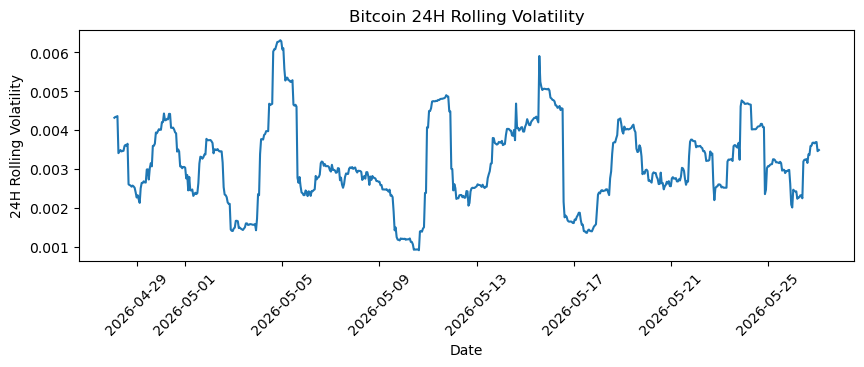

In [211]:
#VOLATILITY TIME
df["rolling_vol_24h"] = df["return"].rolling(window = 24).std()

plt.figure(figsize = (10, 3))
plt.plot(df["date"], df["rolling_vol_24h"])
plt.xlabel("Date")
plt.ylabel("24H Rolling Volatility")
plt.title("Bitcoin 24H Rolling Volatility")
plt.xticks(rotation=45)
plt.show()



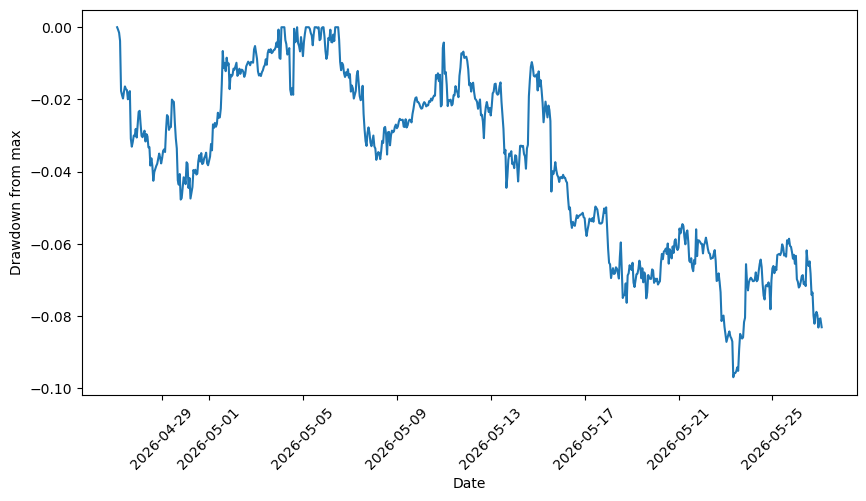

In [212]:
#Drawdown

df["running_max"] = df["price"].cummax()
# WARNING on Lookback Bias: 
# .cummax() calculates the peak starting ONLY from the first row of this slice.
# Since this is a 1-month dataset, it ignores historical BTC peaks outside this range.
# For a true absolute drawdown, the dataset must include inception/all-time data,
# or 'running_max' must be initialized with the asset's true historical ATH.




df["drawdown"] = (df["price"] - df["running_max"]) / df["running_max"]


plt.figure(figsize= (10, 5))
plt.plot(df["date"], df["drawdown"])
plt.xlabel("Date")
plt.ylabel("Drawdown from max")
plt.xticks(rotation = 45)
plt.show()

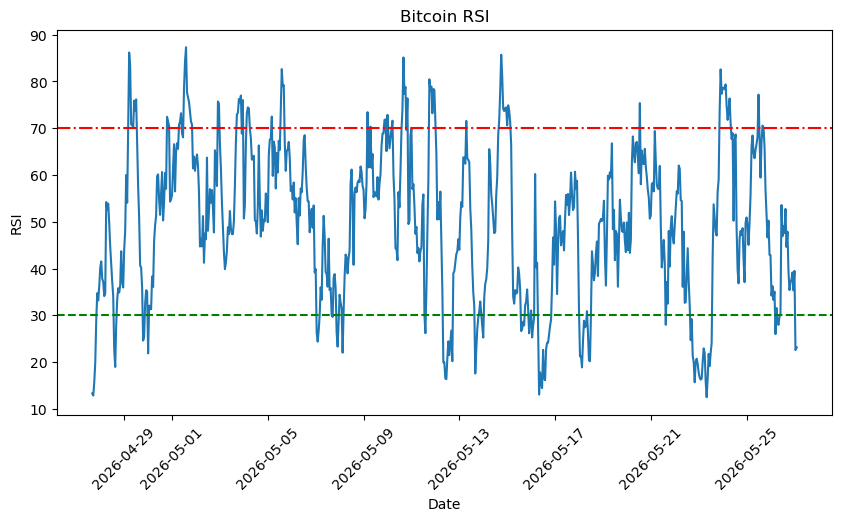

In [213]:

#RELATIVE STRENGTH INDEX

window = 14

df.columns

df["price_change"] = df["price"].diff()

df["gain"] = df["price_change"].clip(lower = 0)
df["loss"] = -df["price_change"].clip(upper = 0)

df["avg_gain"] = df["gain"].rolling(window).mean()
df["avg_loss"] = df["loss"].rolling(window).mean()


df["rs"] = df["avg_gain"] / df["avg_loss"]
# RS: Raw ratio of gains vs. losses (shows who is winning the tug-of-war).

df["rsi"] = 100 - (100 / (1 + df["rs"]))
# RSI: Squashes the RS ratio into a clean 0-100 scale to flag 30/70 extremes.

plt.figure(figsize= (10, 5 ))
plt.plot(df["date"], df["rsi"])
plt.axhline(y = 70, linestyle = "dashdot", color = "red")
plt.axhline(y = 30, linestyle = "--", color = "green")

plt.xlabel("Date")
plt.ylabel("RSI")
plt.title("Bitcoin RSI")
plt.xticks(rotation=45)
plt.show()

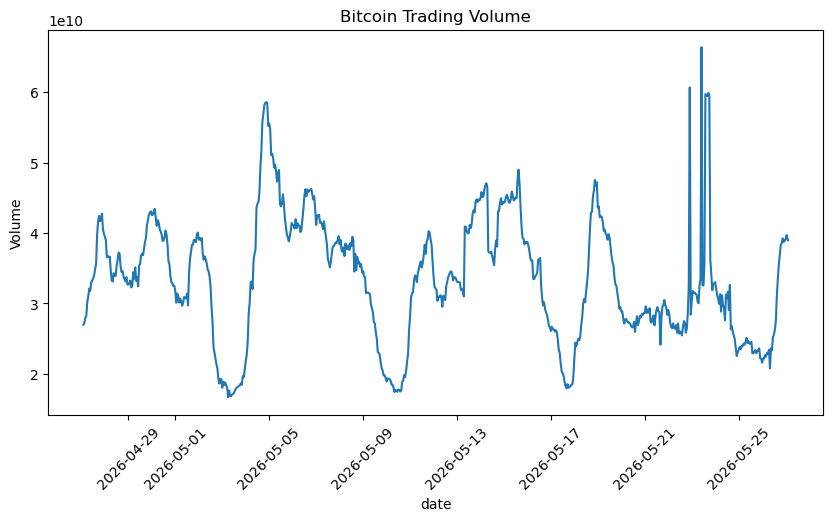

In [214]:
#Volume analysis

volume = data["total_volumes"]

volume_df = pd.DataFrame(volume, columns = ["timestamp" , "volume"])
volume_df["date"] = pd.to_datetime(volume_df["timestamp"], unit= "ms")
volume_df = volume_df[["date", "volume"]]

df.columns # simply just to check

df = df.merge(volume_df, on = "date", how = "left")


plt.figure(figsize = (10, 5))
plt.plot(df["date"], df["volume"])
plt.xlabel("date")
plt.ylabel("Volume")
plt.title("Bitcoin Trading Volume")
plt.xticks(rotation=45)
plt.show()


In [215]:
latest = df.iloc[-1]

signals = []

if latest["price"] > latest["ma_24h"]:
    signals.append("Price above 24H moving average")
else:
    signals.append("Price below 24H moving average")

if latest["rsi"] > 70:
    signals.append("RSI overbought")
elif latest["rsi"] < 30:
    signals.append("RSI oversold")
else:
    signals.append("RSI neutral")

if latest["rolling_vol_24h"] > df["rolling_vol_24h"].mean():
    signals.append("Volatility above average")
else:
    signals.append("Volatility below average")

signals

if latest["price"] > latest["ma_24h"] and latest["rsi"] < 70:
    market_label = "Bullish / healthy momentum"
elif latest["price"] < latest["ma_24h"] and latest["rsi"] > 30:
    market_label = "Weak momentum"
elif latest["rsi"] > 70:
    market_label = "Potentially overbought"
elif latest["rsi"] < 30:
    market_label = "Potentially oversold"
else:
    market_label = "Neutral"

market_label

'Potentially oversold'

<h1> FUNCTIONS <H1>

In [216]:
#FUNCTION 1:  get price data
def get_coin_data(coin_id = "bitcoin", days = 30):
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"

    params = {
        "vs_currency" : "usd",
        "days" : days
    }

    response = requests.get(url, params = params)
    data = response.json()


    price_df = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
    volume_df = pd.DataFrame(data["total_volumes"], columns=["timestamp", "volume"])

    price_df["date"] = pd.to_datetime(price_df["timestamp"], unit = "ms") 
    volume_df["date"] = pd.to_datetime(volume_df["timestamp"], unit = "ms") 


    df = pd.merge(
        price_df[["date", "price"]],
        volume_df[["date", "volume"]],
        how = "left",
        on = "date")

    return df

In [217]:
#FUNCTION 2:  Analytics

def add_analytics(df):
    
    df = df.copy()

    df["return"] = df["price"].pct_change()
    df["return_percent"] = df["return"] * 100

    df["ma_24h"] = df["price"].rolling(window=24).mean()
    df["ma_7d"] = df["price"].rolling(window=24*7).mean()

    df["rolling_vol_24h"] = df["return"].rolling(window=24).std()

    df["running_max"] = df["price"].cummax()
    df["drawdown"] = (df["price"] - df["running_max"]) / df["running_max"]

    window = 14
    df["price_change"] = df["price"].diff()
    df["gain"] = df["price_change"].clip(lower=0)
    df["loss"] = -df["price_change"].clip(upper=0)
    df["avg_gain"] = df["gain"].rolling(window=window).mean()
    df["avg_loss"] = df["loss"].rolling(window=window).mean()
    df["rs"] = df["avg_gain"] / df["avg_loss"]
    df["rsi"] = 100 - (100 / (1 + df["rs"]))
    return df

<h2> TEST <h2>

In [218]:
btc_df = get_coin_data("bitcoin", 30)
btc_df = add_analytics(btc_df)

btc_df.columns



Index(['date', 'price', 'volume', 'return', 'return_percent', 'ma_24h',
       'ma_7d', 'rolling_vol_24h', 'running_max', 'drawdown', 'price_change',
       'gain', 'loss', 'avg_gain', 'avg_loss', 'rs', 'rsi'],
      dtype='object')

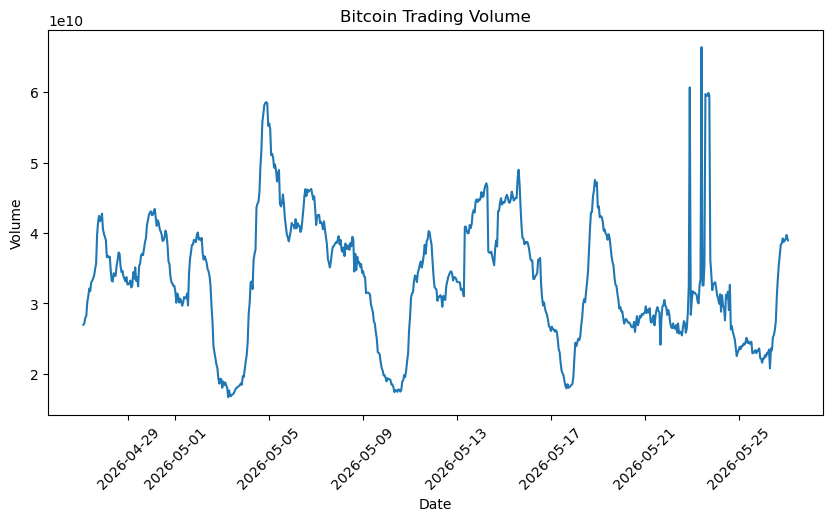

In [219]:
#Volume chart :

plt.figure(figsize=(10, 5))

plt.plot(btc_df["date"], btc_df["volume"])

plt.xlabel("Date")
plt.ylabel("Volume")
plt.title("Bitcoin Trading Volume")
plt.xticks(rotation=45)
plt.show()

In [225]:
#SIGNALS :

def generate_signals(df):
    latest = df.iloc[-1]
    signals = []

    if latest["price"] > latest["ma_24h"]:
        signals.append("Price above 24H moving average")
    else:
        signals.append("Price below 24H moving average")

    if latest["rsi"] > 70:
        signals.append("RSI overbought")
    elif latest["rsi"] < 30:
        signals.append("RSI oversold")
    else:
        signals.append("RSI neutral")

    if latest["rolling_vol_24h"] > df["rolling_vol_24h"].mean():
        signals.append("Volatility above average")
    else:
        signals.append("Volatility below average")

    if latest["volume"] > df["volume"].mean():
        signals.append("Volume above average")
    else:
        signals.append("Volume below average")

    return signals


signals = generate_signals(btc_df)
signals

['Price below 24H moving average',
 'RSI oversold',
 'Volatility above average',
 'Volume above average']

In [222]:
#MARKET LABELS:

def get_market_label(df):
    latest = df.iloc[-1]

    if latest["price"] > latest["ma_24h"] and latest["rsi"] < 70:
        return "Bullish / healthy momentum"
    elif latest["price"] < latest["ma_24h"] and latest["rsi"] > 30:
        return "Weak momentum"
    elif latest["rsi"] > 70:
        return "Potentially overbought"
    elif latest["rsi"] < 30:
        return "Potentially oversold"
    else:
        return "Neutral"


market_label = get_market_label(btc_df)
market_label

'Potentially oversold'

In [229]:
coins = {
    "Bitcoin": "bitcoin",
    "Ethereum": "ethereum",
    "Solana": "solana"
}


coin_name = "Ethereum"
coin_id = coins[coin_name]

coin_df = get_coin_data(coin_id, 30)
coin_df = add_analytics(coin_df)

coin_df.tail()


print(generate_signals(coin_df))

print(get_market_label(coin_df))


['Price below 24H moving average', 'RSI oversold', 'Volatility above average', 'Volume below average']
Potentially oversold


In [236]:
#Im making a multi coin comparison table

comparison_rows = []

for coin_name, coin_id in coins.items():
    temp_df = get_coin_data(coin_id, 40)
    temp_df = add_analytics(temp_df)


    latest = temp_df.iloc[-1]

    comparison_rows.append({
        "coin": coin_name,
        "price": latest["price"],
        "30d_return_percent": ((latest["price"] - temp_df["price"].iloc[0]) / temp_df["price"].iloc[0]) * 100,
        "rsi": latest["rsi"],
        "drawdown_percent": latest["drawdown"] * 100,
        "market_label": get_market_label(temp_df)
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df


,coin,price,30d_return_percent,rsi,drawdown_percent,market_label
0,Bitcoin,75636.268181,1.259495,23.814078,-8.315461,Potentially oversold
1,Ethereum,2067.828387,-11.297787,20.637327,-15.640564,Potentially oversold
2,Solana,83.607148,-4.817350,26.098301,-14.773168,Potentially oversold


In [ ]:
import plotly.express as px


#PRICE CHART 

fig = px.line(
    btc_df,
    x="date",
    y=["price", "ma_24h", "ma_7d"],
    title="Bitcoin Price with Moving Averages"
)

fig.show()

In [240]:
#Returns

fig = px.line(
    btc_df,
    x="date",
    y="return_percent",
    title="Bitcoin Returns Over Time"
)

fig.show()


#volatility chart:

fig = px.line(
    btc_df,
    x="date",
    y="rolling_vol_24h",
    title="Bitcoin 24H Rolling Volatility"
)

fig.show()

#Drawdown chart:

fig = px.line(
    btc_df,
    x="date",
    y="drawdown",
    title="Bitcoin Drawdown"
)

fig.show()


#RSI Chart

fig = px.line(
    btc_df,
    x="date",
    y="rsi",
    title="Bitcoin RSI"
)

fig.add_hline(y=70, line_dash="dash")
fig.add_hline(y=30, line_dash="dash")

fig.show()

In [251]:
#Chart Functions:

def plot_price_chart(df, coin_name):
    fig = px.line(
        df,
        x="date",
        y=["price", "ma_24h", "ma_7d"],
        title=f"{coin_name} Price with Moving Averages"
    )
    return fig


def plot_returns_chart(df, coin_name):
    fig = px.line(
        df,
        x="date",
        y="return_percent",
        title=f"{coin_name} Returns Over Time"
    )
    return fig


def plot_volatility_chart(df, coin_name):
    fig = px.line(
        df,
        x="date",
        y="rolling_vol_24h",
        title=f"{coin_name} 24H Rolling Volatility"
    )
    return fig


def plot_drawdown_chart(df, coin_name):
    fig = px.line(
        df,
        x="date",
        y="drawdown",
        title=f"{coin_name} Drawdown"
    )
    return fig


def plot_rsi_chart(df, coin_name):
    fig = px.line(
        df,
        x="date",
        y="rsi",
        title=f"{coin_name} RSI"
    )

    fig.add_hline(y=70, line_dash="dash")
    fig.add_hline(y=30, line_dash="dash")

    return fig


def plot_volume_chart(df, coin_name):
    fig = px.line(
        df,
        x="date",
        y="volume",
        title=f"{coin_name} Trading Volume"
    )
    return fig



plot_price_chart(btc_df, "Bitcoin").show()
plot_returns_chart(btc_df, "Bitcoin").show()
plot_volatility_chart(btc_df, "Bitcoin").show()
plot_drawdown_chart(btc_df, "Bitcoin").show()
plot_rsi_chart(btc_df, "Bitcoin").show()
plot_volume_chart(btc_df, "Bitcoin").show()